# Imports

In [8]:
import pickle
import json
import sys
import os
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from collections import defaultdict

from matplotlib.backends.backend_pdf import PdfPages

# Data Analysis

## Load Dataset

In [2]:
def load_data( data_loc ):
    """
        Converts pickle to json
        return: json file
    """

    with open(data_loc, 'rb') as infile:
        obj = pickle.load(infile)

    # convert pickle object to json object
    json_obj = json.loads(json.dumps(obj, default=str))
    
    return json_obj

data = load_data( data_loc = "../../paper/code/ml4lp/data-bin/uniprotKB/cfpgen_general_dataset/"  + "experiment.pkl")

print(data)


[{'uniprot_id': 'A1KZ92', 'ipr_numbers': ['IPR000483', 'IPR019791', 'IPR010255', 'IPR037120', 'IPR007110', 'IPR036179', 'IPR013783', 'IPR013098', 'IPR003599', 'IPR003598', 'IPR001611', 'IPR003591', 'IPR032675', 'IPR034824', 'IPR001007'], 'go_numbers': {'C': [], 'F': [], 'P': []}, 'ipr_mapped': [475], 'go_f_mapped': [], 'iprs_in_train': 1, 'iprs_not_in_train': 14, 'length': 1463, 'sequence': 'MEPRLFCWTTLFLLAGWCLPGLPCPSRCLCFKSTVRCMHLMLDHIPQVPQQTTVLDLRFNRIREIPGSAFKKLKNLNTLLLNNNHIRKISRNAFEGLENLLYLYLYKNEIHALDKQTFKGLISLEHLYIHFNQLEMLQPETFGDLLRLERLFLHNNKLSKIPAGSFSNLDSLKRLRLDSNALVCDCDLMWLGELLQGFAQHGHTQAAATCEYPRRLHGRAVASVTVEEFNCQSPRITFEPQDVEVPSGNTVYFTCRAEGNPKPEIIWIHNNHSLDLEDDTRLNVFDDGTLMIRNTRESDQGVYQCMARNSAGEAKTQSAMLRYSSLPAKPSFVIQPQDTEVLIGTSTTLECMATGHPHPLITWTRDNGLELDGSRHVATSSGLYLQNITQRDHGRFTCHANNSHGTVQAAANIIVQAPPQFTVTPKDQVVLEEHAVEWLCEADGNPPPVIVWTKTGGQLPVEGQHTVLSSGTLRIDRAAQHDQGQYECQAVSSLGVKKVSVQLTVKPKALAVFTQLPQDTSVEVGKNINISCHAQGEPQPIITWNKEGVQITESGKFHVDDEGTLTIYDAGFPDQGRYECVARNSFGLAVTNMFLTVTAIQGRQA

## Length vs Frequency

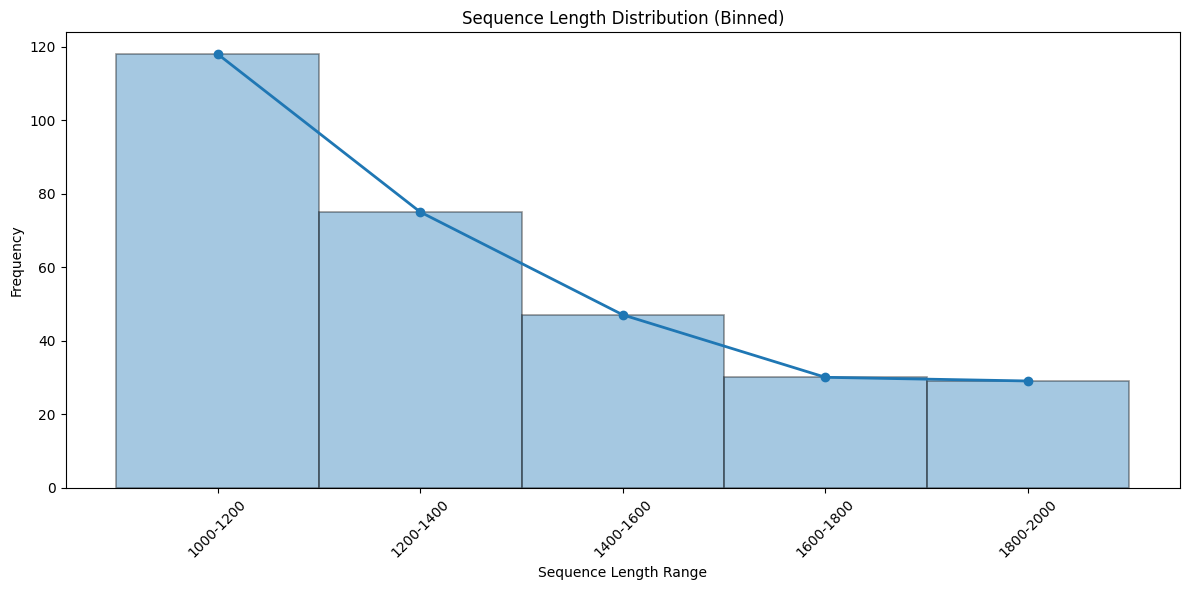

In [16]:

def plot_length_distribution(sequence_list, bin_size=200):

    # Extract lengths
    lengths = [
        entry["length"]
        for entry in sequence_list
        if "length" in entry and entry["length"] is not None
    ]

    if len(lengths) == 0:
        print("No length data found.")
        return

    lengths = np.array(lengths)

    # Create bins
    max_length = lengths.max()
    bins = np.arange(1000, max_length + bin_size, bin_size)

    counts, edges = np.histogram(lengths, bins=bins)

    # Bin centers for plotting
    bin_centers = (edges[:-1] + edges[1:]) / 2

    # Create readable x-label ranges
    bin_labels = [
        f"{int(edges[i])}-{int(edges[i+1])}"
        for i in range(len(edges) - 1)
    ]

    plt.figure(figsize=(12, 6))

    # 1) Bars with black boundary + transparent fill
    plt.bar(
        bin_centers,
        counts,
        width=bin_size,
        edgecolor="black",      # black boundary
        linewidth=1.2,
        alpha=0.4               # transparency
    )

    # 3 & 4) Hard-colored scatter + line overlay
    plt.plot(
        bin_centers,
        counts,
        marker="o",
        linestyle="-",
        linewidth=2,
        markersize=6
    )

    # 2) X labels centered in middle of bars
    plt.xticks(bin_centers, bin_labels, rotation=45, ha="center")

    plt.xlabel("Sequence Length Range")
    plt.ylabel("Frequency")
    plt.title("Sequence Length Distribution (Binned)")
    plt.tight_layout()

    plt.savefig("plots/seq_len_distribution_bin.pdf", format="pdf", bbox_inches="tight")

    plt.show()


plot_length_distribution( data )

## Missing IPR Frequency

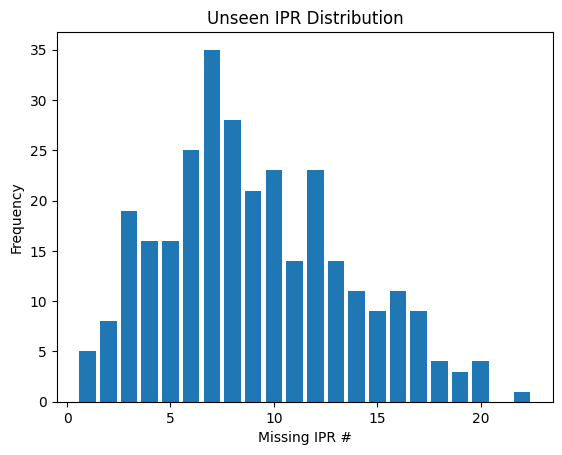

In [15]:
def plot_length_distribution(sequence_list):
    # sequence_list is a LIST of dicts (not dict of dicts)

    # Extract iprs_not_in_train safely
    iprs_not_in_train = [
        entry["iprs_not_in_train"]
        for entry in sequence_list
        if "iprs_not_in_train" in entry and entry["iprs_not_in_train"] is not None
    ]

    # Count frequency
    iprs_not_in_train_counts = Counter(iprs_not_in_train)

    # Sort by sequence length
    sorted_items = sorted(iprs_not_in_train_counts.items())
    x = [item[0] for item in sorted_items]
    y = [item[1] for item in sorted_items]

    # Plot bar chart
    plt.figure()
    plt.bar(x, y)
    plt.xlabel("Missing IPR #")
    plt.ylabel("Frequency")
    plt.title("Unseen IPR Distribution")

    plt.savefig("plots/missing_ipr_freq_bar.pdf", format="pdf", bbox_inches="tight")

    plt.show()

plot_length_distribution( data )

## Length vs Frequency vs Missing IPR

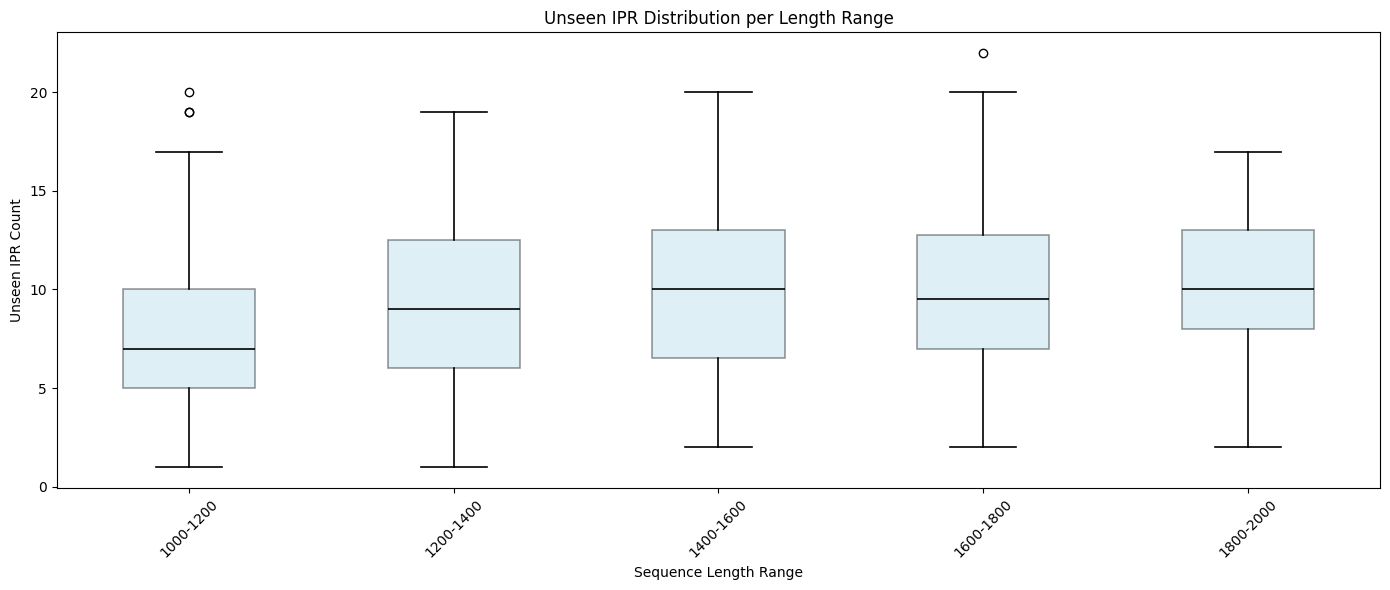

In [ ]:
def plot_length_distribution(sequence_list, bin_size=200):

    # Extract length and missing values
    data = [
        (entry["length"], entry["iprs_not_in_train"])
        for entry in sequence_list
        if entry.get("length") is not None and entry.get("iprs_not_in_train") is not None
    ]

    if len(data) == 0:
        print("No valid length/missing data found.")
        return

    lengths = np.array([d[0] for d in data])
    missing_vals = np.array([d[1] for d in data])

    # Create bins
    max_length = lengths.max()
    bins = np.arange(1000, max_length + bin_size, bin_size)

    # Assign each sequence to a bin
    bin_indices = np.digitize(lengths, bins)

    # Group missing values per bin
    grouped_missing = []
    bin_labels = []

    for i in range(1, len(bins)):
        mask = bin_indices == i
        if np.any(mask):
            grouped_missing.append(missing_vals[mask])
            bin_labels.append(f"{int(bins[i-1])}-{int(bins[i])}")

    if len(grouped_missing) == 0:
        print("No data available after binning.")
        return

    plt.figure(figsize=(14, 6))

    box = plt.boxplot(
        grouped_missing,
        patch_artist=True
    )

    # Transparent boxes with black edges
    for patch in box['boxes']:
        patch.set(facecolor='lightblue', alpha=0.4, edgecolor='black', linewidth=1.2)

    for element in ['whiskers', 'caps', 'medians']:
        for item in box[element]:
            item.set(color='black', linewidth=1.2)

    plt.xticks(range(1, len(bin_labels) + 1), bin_labels, rotation=45, ha="center")

    plt.xlabel("Sequence Length Range")
    plt.ylabel("Unseen IPR Count")
    plt.title("Unseen IPR Distribution per Length Range")
    plt.tight_layout()

    plt.savefig("plots/ipr_box_plot.pdf", format="pdf", bbox_inches="tight")
    
    plt.show()

plot_length_distribution( data )

# Model Comparision

## Load Results

In [35]:
def parse_fasta_to_dict(fasta_loc, model = "cfp"):
    sequences = []

    with open(fasta_loc, "r") as fp:
        entry_id = None
        sequence = ""
        all_info = ""

        for line in fp:
            line = line.strip()
            # print(line)

            if line.startswith(">"):
                sequences.append({
                            "entry_id": entry_id,
                            "all_info": all_info + "\n" + sequence,
                        })

                if( model == "cfp" ):
                    entry_id = line.split("=")[1].split("_")[0]
                else:
                    entry_id = line.split("_")[1].split("_")[0]
                all_info = line
            else:
                sequence = line
                

    return sequences

results_loc_dplm = "../../paper/code/ml4lp/generation-results/dplm_650m/dplm_t500_len200.fasta"
results_loc_cfp = "../../paper/code/ml4lp/generation-results/cfpgen_650m_ipr.fasta"
result_seq_cfp = parse_fasta_to_dict( results_loc_cfp )
result_seq_dplm = parse_fasta_to_dict( results_loc_dplm, model = "dplm" )

result_seq_cfp = result_seq_cfp[1:]
result_seq_dplm = result_seq_dplm[1:]

print(result_seq_cfp)
print(result_seq_dplm)

[{'entry_id': 'A1KZ92', 'all_info': '>SEQUENCE_ID=A1KZ92_L=3619\nKDEEKEKEEEDEKKKSKEEEEKEEDEDEEKKKYEEEKEKEKEEKEDNKDKDEDGEEEDEDKEEENKEEEKEKNKKKDKEENEDDEKEKNEEKDKDEEEEDKENDKENEKDEEEKDEEEDEEEEEEEEDEDKDEDEKKEKDKEKKEKDKDKDDEEDEDEEDEEDEDKDEKEDKKETEEKKDEEKEEDDKEEDEKDKKNKIDKKKEDKDKDEDDKDKMEDEEDKNDKKKNEDDEEEKDKEEEDEDEDDEEEEDDDKEKKDKDEKSDDEEEEEKEDKDDDDEEDKKDEEENKEKDDKVDEDEDDNEEEKKGEEDEKDEEDEDEKDDDDKDEEEEDDEDDEEKDEKEDKEDEEEDNDKEDDEEDKDKDEEEDEDEDDDDDKKEEEEEEENEDDENDDKDEKDEDDDDDNDDDDDEDKDDNKNNNNNKDKDDDNDDDEDEDEKDDEKKKDNEKNNMKKDNDNDDDEDDNEDEKDDDKDKNNNNNNNDNNKNNNNKKDKDNEEKENDDNNENEKDNNNNNKKDNNDNEDNDDKNNNDEKNNNNNKNEKDNNNKNDDNNDEEKENKNNNKKKNKENDNNENDNDNEKEDKMDNNNDKNNNDNNNNNNDNEDDNKKDNNDNNNENDKDKDKDDNNKNDNKKNKKKGNDDDDEEDNDNNNEEKEKENNDNNNNNEKDDKNNNKNSNNNNNNNDDNDNKNNKDNEDKDNNNDENNDENNEDNDDKENKNKKEKKDKENKKKEDNKDENKDNDNNKNNDNDNNKDNDEDEKEDDNDKKEDKDDKDKDKENNKDNDDKNNNKNDKNEDKDDNEENDENKDDKKKENDDKNENDDNKKDEEKNEKDSNEKDKDKDDEEENNKKKNKDDKNEKDNDDENDERKKNKDDEDENDEKDDKNNNVDKDKEDDDKNNDDNNNCNNDDDKEDDEDDDEDKNDENDEKKDDNDDK

## Saving into respective dirs

In [ ]:
def save_pkl_file(data, file_path):
    with open(file_path, 'wb') as f:
        pickle.dump(data, f)
    print(f"Updated data saved to {file_path}")

def save_fasta_file( data, file_path ):
    with open(file_path, 'w') as f:
        f.write('\n'.join(data))



def generate_folder_dir( root_dir, fasta, gt, column_imp = "iprs_not_in_train" ):
    """
        This function generates directory for the requirement

        Requirement:
        Steps:
            (1) in a new directory at generation-results/analysis
            (2) new folders with missing_ipr (range # missing at gt)
            (3) each folder contains experiment.pkl and fasta of respective gt's missing file
            (4) in gpu bash, loop over each directory and at generation-results/analysis, 
                    save json with key as #missing_ipr and value as the eval metric
            (5) plot on this json.

        :param column_imp = btwn "iprs_not_in_train"/"length"
    """

    # (i) collecting all unique missing_ipr_counts
    ipr_dis_list = list(set([
            entry["iprs_not_in_train"]
            for entry in gt
            if "iprs_not_in_train" in entry and entry["iprs_not_in_train"] is not None
        ]))
    
    # (ii) distributing to their respective location 
    fasta_dump_list = []

    for missing_count in ipr_dis_list:

        # (ii.i) find all such missing count at gt, 
        res = [sub for sub in gt if sub['iprs_not_in_train'] == missing_count]
        res = res if res else None

        # (ii.ii) grab the entry_id, 
        # (ii.iii) collect those samples from .fasta

        # Collect all uniprot_ids from rest into a set (fast lookup)
        rest_ids = {re["uniprot_id"] for re in res if "uniprot_id" in re}

        # Filter fasta items whose entry_id matches rest uniprot_id
        fasta_dump_list = [
            item["all_info"]
            for item in fasta
            if item.get("entry_id") in rest_ids
        ]

        print(fasta_dump_list)
        
        # (iv) create new folder
        new_dir = root_dir + f"missing_{missing_count}"
        os.makedirs(new_dir)

        # save files
        save_fasta_file( fasta_dump_list, new_dir + f"/cfpgen_650m_ipr.fasta")
        save_pkl_file( res, new_dir  + "/experiment.pkl"  )


generate_folder_dir( root_dir="../../paper/code/ml4lp/generation-results/", fasta=result_seq, gt=data )

['>SEQUENCE_ID=P10745_L=1099\nRAERDERERDALERERDELDAERARLDEERARLDAERDELDARERELDAERDALERERAELAERRAELERERDALDAERADARDDTERERLARERDELERERERLERERDERAERDAARAELERERAELERERERDERARDERERARRDELDARAAEVERERAELDARERELERAERELERRAARDEDEADARERAERADDERAERERADDERAEREREAARRAAEERAARDELDARERALARERDDLARERAERERERDAERDERDARERDRDERERELDAERDERVAERERERDAARERAERERAERERERAERDRAERERERRADAERERAERERAERERAERVRDERERERAERERERDAERAELDARRDELERERERLARERAERDDERDDDVADERERAAERERLERERDELEREREALDARAERLDDDAERDALERERAELDARRDAQRDARARAERDERAERAERDAVDDARDAVDDARADRDALDARERELERERERLDERRAALDAERDALDARERELERAERALERRAADADDADADADADADADADAERDDAERAERERLDARERALDEREQALDARADELDAERDALERAERDAESDDAERDAERERDADAERDALEARRDELARERDALEAERDELERARADAERDADADADADEREAALARERDALERNRDELRERAERAERADADARDELARERDALERERAELDERERALDARERALRERAADADRDADEPDADAAPDADADADDAAAADDADADADERAPLERERAELEAERDALERDADADADAADADADADDDDADADDEPDDDADERDDDADEADDDADEADDDADDADADAEPDDDADEAERDADAAPADDDARDAERERLERELDAAADDDARDAVDAELDALDERERALERALDDADDDDERDALERALDDVRAQRDDLEARRDAEDADADADAERDAERDDADDA

FileExistsError: [WinError 183] Cannot create a file when that file already exists: '../../paper/code/ml4lp/generation-results/missing_1'

# Model Analysis

## Reading and preprocessing

In [3]:

def read_json( loc ):

    with open(loc, "r", encoding="utf-8") as f:
        result = json.load(f)

    return result

def preprocess_json( result ):

    """
    Processing key
    """

    processed_result = {}

    for key, value in result.items():
        new_key = int(key)
        processed_result[new_key] = value
    
    return processed_result

result_cfp = read_json( loc = "../../paper/code/ml4lp/generation-results/eval_log_cfp.json" )
result_dplm = read_json( loc = "../../paper/code/ml4lp/generation-results/eval_log_dplm.json" )

#make sure to process the jsons' values before running these
processed_result_cfp = preprocess_json( result_cfp )
processed_result_dplm = preprocess_json( result_dplm )

print(processed_result_cfp)
print(processed_result_dplm)
    

{1000: 0.432, 1200: 0.486, 1400: 0.527, 1600: 0.558, 1800: 0.588}
{1000: 0.314, 1200: 0.354, 1400: 0.388, 1600: 0.447, 1800: 0.434}


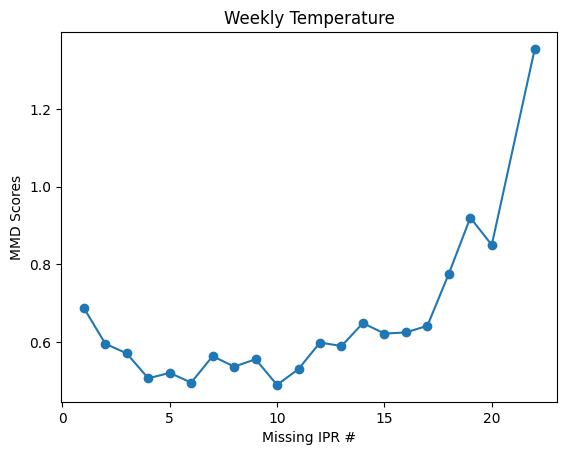

In [12]:

missing_cnt = list(processed_result_cfp.keys())           # list() needed for python 3.x
mmd_scores = list(processed_result_cfp.values())        # ditto

plt.plot(missing_cnt, mmd_scores, marker='o')
plt.title('Weekly Temperature')
plt.ylabel('MMD Scores')
plt.xlabel('Missing IPR #')
plt.show()


## Re-updating the whole pipeline with onboarding of dplm and sequence_lengths are primary concern

In [ ]:
def save_pkl_file(data, file_path):
    with open(file_path, 'wb') as f:
        pickle.dump(data, f)
    print(f"Updated data saved to {file_path}")

def save_fasta_file( data, file_path ):
    with open(file_path, 'w') as f:
        f.write('\n'.join(data))



def generate_folder_dir( root_dir, fasta, gt, column_imp = "length", model = None ):
    """
        This function generates directory for the requirement

        Requirement:
        Steps:
            (1) in a new directory at generation-results/analysis
            (2) new folders with missing_ipr (range # missing at gt)
            (3) each folder contains experiment.pkl and fasta of respective gt's missing file
            (4) in gpu bash, loop over each directory and at generation-results/analysis, 
                    save json with key as #missing_ipr and value as the eval metric
            (5) plot on this json.

        :param column_imp = btwn "iprs_not_in_train"/"length"
    """

    # (i) collecting all unique missing_ipr_counts
    length_dis_list = list(set([
            entry["length"]
            for entry in gt
            if "length" in entry and entry["length"] is not None
        ]))
    
    length_dis_list.sort()

    # print( f"length_dis_list:\n{length_dis_list}" )

    concerned_length_lst = np.arange( 1000, 2000, 200 )
    
    # # (ii) distributing to their respective location 
    fasta_dump_list = []

    # # bin_size=200

    for concerned_length in concerned_length_lst:

    #     # (ii.i) find all such missing count at gt, 
        # print( f"concerned_length:{concerned_length}" )

        range_len_res = [sub for sub in gt if sub['length'] >= (concerned_length) and sub['length'] <= (concerned_length + 200)]
        range_len_res = range_len_res if range_len_res else None

        # print( f"range_len_res:{range_len_res}" )

    #     # (ii.ii) grab the entry_id, 
    #     # (ii.iii) collect those samples from .fasta

    #     # Collect all uniprot_ids from rest into a set (fast lookup)
        rest_ids = {re["uniprot_id"] for re in range_len_res if "uniprot_id" in re}

    #     # Filter fasta items whose entry_id matches rest uniprot_id
        fasta_dump_list = [
            item["all_info"]
            for item in fasta
            if item.get("entry_id") in rest_ids
        ]

        print(fasta_dump_list)
        
    #     # (iv) create new folder
        new_dir = root_dir + f"bin_{concerned_length}"

        if (model == "cfp"):
            os.makedirs(new_dir)

    #     # save files
            fasta_save_file_loc = f"/cfpgen_650m_ipr.fasta"
            save_fasta_file( fasta_dump_list, new_dir + fasta_save_file_loc) #saving to avoid experiment.pkl to save
            save_pkl_file( range_len_res, new_dir  + "/experiment.pkl"  )

        else:
            fasta_save_file_loc = "/dplm_t500_len200.fasta"
            save_fasta_file( fasta_dump_list, new_dir + fasta_save_file_loc)


# generate_folder_dir( root_dir="../../paper/code/ml4lp/generation-results/", fasta=result_seq_cfp, gt=data, model = "cfp" )
print("-----------DPLM------------------")
generate_folder_dir( root_dir="../../paper/code/ml4lp/generation-results/", fasta=result_seq_dplm, gt=data, model = "dplm" )

-----------DPLM------------------
concerned_length:1000
range_len_res:[{'uniprot_id': 'A5A3E0', 'ipr_numbers': ['IPR004000', 'IPR020902', 'IPR004001', 'IPR002110', 'IPR036770', 'IPR043129', 'IPR039497'], 'go_numbers': {'C': [], 'F': [], 'P': []}, 'ipr_mapped': [1089], 'go_f_mapped': [], 'iprs_in_train': 1, 'iprs_not_in_train': 6, 'length': 1075, 'sequence': 'MVVEVDSMPAASSVKKPFGLRSKMGKWCCRCFPCCRESGKSNVGTSGDHDDSAMKTLRSKMGKWCRHCFPCCRGSGKSNVGASGDHDDSAMKTLRNKMGKWCCHCFPCCRGSSKSKVGAWGDYDDSAFMEPRYHVRGEDLDKLHRAAWWGKVPRKDLIVMLRDTDVNKQDKQKRTALHLASANGNSEVVKLLLDRRCQLNVLDNKKRTALIKAVQCQEDECALMLLEHGTDPNIPDEYGNTTLHYAIYNEDKLMAKALLLYGADIESKNKHGLTPLLLGVHEQKQQVVKFLIKKKANLNALDRYGRTALILAVCCGSASIVSLLLEQNIDVSSQDLSGQTAREYAVSSHHHVICQLLSDYKEKQMLKISSENSNPEQDLKLTSEEESQRFKGSENSQPEKMSQEPEINKDGDREVEEEMKKHESNNVGLLENLTNGVTAGNGDNGLIPQRKSRTPENQQFPDNESEEYHRICELLSDYKEKQMPKYSSENSNPEQDLKLTSEEESQRLKGSENGQPEKRSQEPEINKDGDRELENFMAIEEMKKHRSTHVGFPENLTNGATAGNGDDGLIPPRKSRTPESQQFPDTENEEYHSDEQNDTQKQFCEEQNTGILHDEILIHEEKQIEVVEKMNSELSLSCK

## Plot

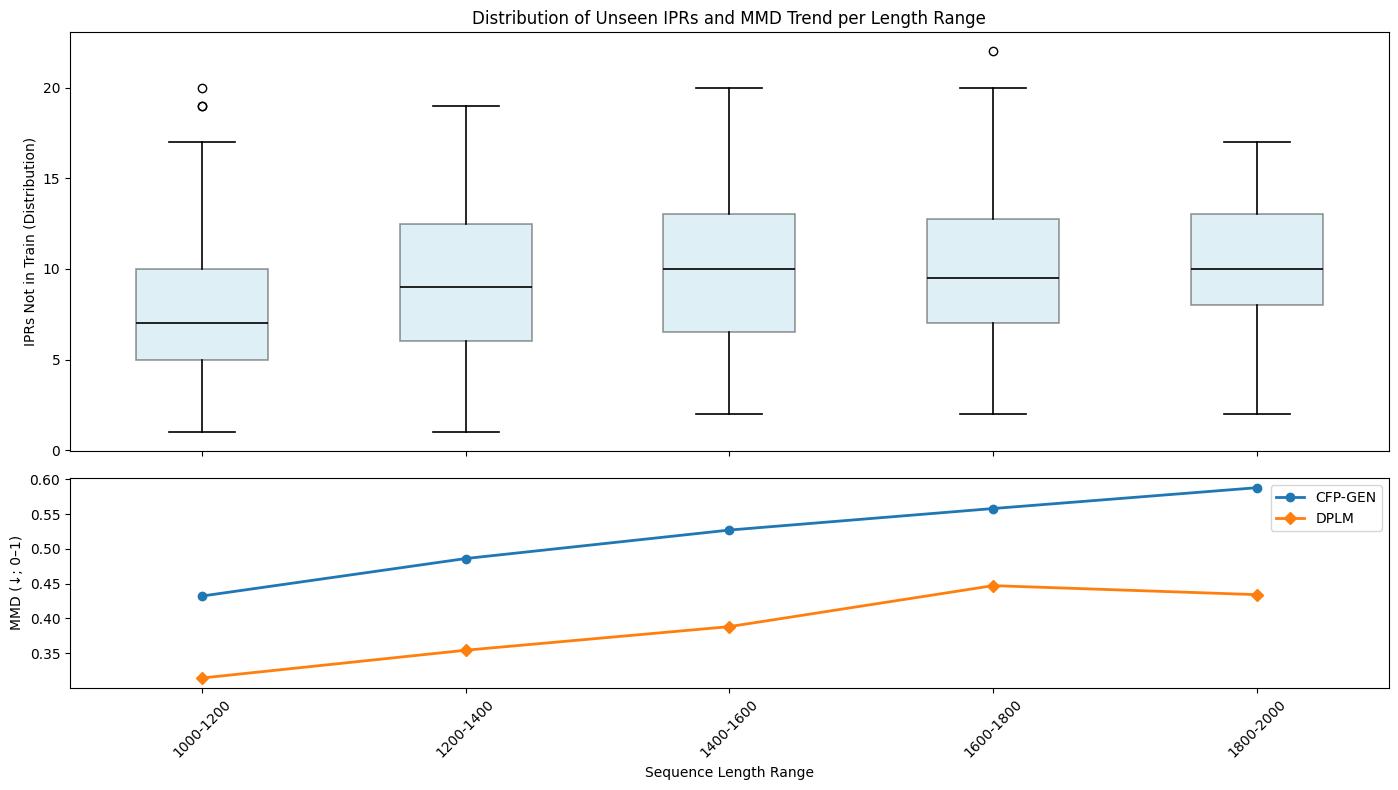

In [10]:
import matplotlib.pyplot as plt
import numpy as np


def plot_length_distribution(sequence_list, scatter_dict1=None, scatter_dict2=None, bin_size=200):

    # Extract length and missing values
    data = [
        (entry["length"], entry["iprs_not_in_train"])
        for entry in sequence_list
        if entry.get("length") is not None and entry.get("iprs_not_in_train") is not None
    ]

    if len(data) == 0:
        print("No valid length/missing data found.")
        return

    lengths = np.array([d[0] for d in data])
    missing_vals = np.array([d[1] for d in data])

    # Create bins
    max_length = lengths.max()
    bins = np.arange(1000, max_length + bin_size, bin_size)

    # Assign each sequence to a bin
    bin_indices = np.digitize(lengths, bins)

    grouped_missing = []
    bin_labels = []
    valid_bin_ranges = []

    for i in range(1, len(bins)):
        mask = bin_indices == i
        if np.any(mask):
            grouped_missing.append(missing_vals[mask])
            bin_labels.append(f"{int(bins[i-1])}-{int(bins[i])}")
            valid_bin_ranges.append((bins[i-1], bins[i]))

    if len(grouped_missing) == 0:
        print("No data available after binning.")
        return

    positions = np.arange(1, len(grouped_missing) + 1)

    # Create stacked subplots with shared x-axis
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(14, 8), sharex=True,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    # -------- TOP: Boxplot --------
    box = ax1.boxplot(
        grouped_missing,
        positions=positions,
        patch_artist=True
    )

    for patch in box['boxes']:
        patch.set(facecolor='lightblue', alpha=0.4, edgecolor='black', linewidth=1.2)

    for element in ['whiskers', 'caps', 'medians']:
        for item in box[element]:
            item.set(color='black', linewidth=1.2)

    ax1.set_ylabel("IPRs Not in Train (Distribution)")
    ax1.set_title("Distribution of Unseen IPRs and MMD Trend per Length Range")

    # -------- BOTTOM: Line plots --------
    def map_to_positions(scatter_dict):
        xs = []
        ys = []
        for length_key, value in scatter_dict.items():
            for idx, (low, high) in enumerate(valid_bin_ranges):
                if low <= length_key < high:
                    xs.append(idx + 1)
                    ys.append(value)
                    break
        return xs, ys

    if scatter_dict1 is not None:
        x1, y1 = map_to_positions(scatter_dict1)
        ax2.plot(x1, y1, marker="o", linewidth=2, label="CFP-GEN")

    if scatter_dict2 is not None:
        x2, y2 = map_to_positions(scatter_dict2)
        ax2.plot(x2, y2, marker="D", linewidth=2, label="DPLM")

    ax2.set_ylabel("MMD (↓; 0–1)")
    ax2.set_xlabel("Sequence Length Range")
    ax2.legend(loc="upper right")

    plt.xticks(positions, bin_labels, rotation=45, ha="center")

    plt.tight_layout()
    plt.show()

    
    with PdfPages("plots/mmd_ipr.pdf") as pdf:
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)


# Example usage
plot_length_distribution(
    data,
    scatter_dict1=processed_result_cfp,
    scatter_dict2=processed_result_dplm
)